Factor relative performance:
Categorical features

In [1]:
# Import libraries:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import os

In [2]:
import os
os.chdir('C:/Users/p528552/OneDrive - South African Reserve Bank/Documents/1. MEng - Data Science/1. Project_2025/Data/factor_timing/data_input')

In [3]:
df_factors = pd.read_csv("factor_returns.csv", parse_dates=['Date'])
df_factors = df_factors.set_index('Date')

In [4]:
# --- Data Upload ---
def load_data(file_path):
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    return df

file_path = ('factor_returns.csv')
df=load_data(file_path)

# Ensure data type is: float
print(df.dtypes)

Momentum    float64
Value       float64
Quality     float64
dtype: object


In [5]:
"""
# --- Relative Returns Calculation ---
def relative_returns(df):
    for factor in ['Momentum', 'Value', 'Quality']:
        df[f'{factor}_Relative'] = df[factor] - df['Benchmarks']
    return df

df_rel_returns = relative_returns(df)
print(df_rel_returns)
"""

"\n# --- Relative Returns Calculation ---\ndef relative_returns(df):\n    for factor in ['Momentum', 'Value', 'Quality']:\n        df[f'{factor}_Relative'] = df[factor] - df['Benchmarks']\n    return df\n\ndf_rel_returns = relative_returns(df)\nprint(df_rel_returns)\n"

In [6]:
# --- Relative Performance Between Factors ---
def factor_relative_returns(df, factors=None):

    if factors is None:
        factors = ['Momentum', 'Value', 'Quality']
    
    # Calculate all pairwise relative returns
    for i, factor1 in enumerate(factors):
        for j, factor2 in enumerate(factors):
            if i < j:  # Avoid duplicates and self-comparisons
                rel_col = f'{factor1}_vs_{factor2}'
                df[rel_col] = df[factor1] - df[factor2]
    
    return df

# Usage
df_factor_rel = factor_relative_returns(df.copy())
print(df_factor_rel)

            Momentum     Value   Quality  Momentum_vs_Value  \
Date                                                          
2007-03-05  0.018613  0.015753 -0.010966           0.002859   
2007-03-12 -0.012887 -0.020257  0.048512           0.007370   
2007-03-19  0.060268  0.052751  0.014917           0.007518   
2007-03-26  0.022670  0.007935  0.007713           0.014735   
2007-04-02  0.010079  0.009888  0.018702           0.000191   
...              ...       ...       ...                ...   
2025-03-03  0.049395  0.011621  0.076581           0.037774   
2025-03-10 -0.009996 -0.002634  0.041062          -0.007362   
2025-03-17  0.040341  0.006385  0.018397           0.033956   
2025-03-24  0.008068 -0.006651  0.020056           0.014719   
2025-03-31 -0.017642 -0.096445 -0.010625           0.078803   

            Momentum_vs_Quality  Value_vs_Quality  
Date                                               
2007-03-05             0.029579          0.026719  
2007-03-12            -0

In [7]:
# --- Cumulative Relative Returns Calculation ---
factors = ['Momentum_vs_Value', 'Momentum_vs_Quality', 'Value_vs_Quality']
def cumulative_relative_returns(df):
    for factor in factors:
        # Calculate cumulative product of (1 + relative return)
        cumulative_returns = (1 + df[factor]).cumprod() - 1
        df[f'{factor}_Cumulative'] = cumulative_returns
    return df

# Apply the function to your dataframe
df_cumulative = cumulative_relative_returns(df_factor_rel.copy())
print(df_cumulative)

            Momentum     Value   Quality  Momentum_vs_Value  \
Date                                                          
2007-03-05  0.018613  0.015753 -0.010966           0.002859   
2007-03-12 -0.012887 -0.020257  0.048512           0.007370   
2007-03-19  0.060268  0.052751  0.014917           0.007518   
2007-03-26  0.022670  0.007935  0.007713           0.014735   
2007-04-02  0.010079  0.009888  0.018702           0.000191   
...              ...       ...       ...                ...   
2025-03-03  0.049395  0.011621  0.076581           0.037774   
2025-03-10 -0.009996 -0.002634  0.041062          -0.007362   
2025-03-17  0.040341  0.006385  0.018397           0.033956   
2025-03-24  0.008068 -0.006651  0.020056           0.014719   
2025-03-31 -0.017642 -0.096445 -0.010625           0.078803   

            Momentum_vs_Quality  Value_vs_Quality  \
Date                                                
2007-03-05             0.029579          0.026719   
2007-03-12           

In [8]:
# Trend Scanning Functions
def tval_lin(close):

    # Computes t-values on sample determined by look-forward window L
    x = np.ones((close.shape[0], 2))
    x[:, 1] = np.arange(close.shape[0])
    ols = sm.OLS(close, x).fit()
    return ols.tvalues[1]

def get_bins(molecule, close, span):
    # Pick the value of L that maximizes t-values

    out = pd.DataFrame(index=molecule, columns=['t1', 'tval', 'bin'])
    hrzns = range(*span)
    
    for dt0 in molecule:
        df0 = pd.Series(dtype=float)
        iloc0 = close.index.get_loc(dt0)
        
        if iloc0 + max(hrzns) > len(close):
            continue
            
        for hrzn in hrzns:
            dt1 = close.index[iloc0 + hrzn - 1]
            df1 = close.loc[dt0:dt1]
            df0.loc[dt1] = tval_lin(df1.values)
            
        if not df0.empty:
            dt1 = df0.replace([-np.inf, np.inf, np.nan], 0).abs().idxmax()
            tval = df0[dt1]
            
            # Create binary label based on t-value significance and sign
            if abs(tval) >= 0:
                bin_label = 1 if tval > 0 else 0  # 1=up, 0=down
            else:
                bin_label = np.nan  # Not significant, will be dropped
                
            out.loc[dt0, ['t1', 'tval', 'bin']] = dt1, tval, bin_label


    out['t1'] = pd.to_datetime(out['t1'])
    out['bin'] = pd.to_numeric(out['bin'], downcast='signed')
    return out.dropna(subset=['bin'])

In [9]:
# Execute:
if __name__ == "__main__":
    # Load data
    file_path = 'factor_returns.csv'
    df = load_data(file_path)
    
    # Calculate returns
    df = factor_relative_returns(df)
    df = cumulative_relative_returns(df)
    
    # Apply trend scanning to each factor
    span = (1,12)
    

    factors_to_scan = ['Momentum_vs_Value', 'Value_vs_Quality', 'Momentum_vs_Quality']
    
    for factor in factors_to_scan:
        col_name = f'{factor}_Cumulative'
        if col_name not in df.columns:
            print(f"Warning: Column '{col_name}' not found. Skipping {factor}.")
            continue

        print(f"\nProcessing {factor}...")
        print(f"Data shape: {df[col_name].shape}")
        print(f"NaN values: {df[col_name].isna().sum()}")
        
        # Get trend labels with error handling
        try:
            trend_labels = get_bins(df.index, df[col_name], span)
            
            # Check if trend_labels is None
            if trend_labels is None:
                print(f"Error: get_bins() returned None for {factor}")
                continue
                
            print(f"Trend labels shape: {trend_labels.shape}")
            print(f"Trend labels index type: {type(trend_labels.index)}")
            
            # Ensure proper index alignment
            if not df.index.equals(trend_labels.index):
                print("Index mismatch - reindexing trend labels...")
                trend_labels = trend_labels.reindex(df.index)
            
            # Merge labels back to original DataFrame
            label_col_name = f'{factor}_trend'
            df[label_col_name] = trend_labels['bin']  
            
            print(f"Successfully added trend labels for {factor}")
            print(f"Non-NaN trend values: {df[label_col_name].notna().sum()}")
            
        except Exception as e:
            print(f"Error processing {factor}: {e}")
            import traceback
            traceback.print_exc()



Processing Momentum_vs_Value...
Data shape: (944,)
NaN values: 0
Trend labels shape: (934, 3)
Trend labels index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index mismatch - reindexing trend labels...
Successfully added trend labels for Momentum_vs_Value
Non-NaN trend values: 934

Processing Value_vs_Quality...
Data shape: (944,)
NaN values: 0
Trend labels shape: (934, 3)
Trend labels index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index mismatch - reindexing trend labels...
Successfully added trend labels for Value_vs_Quality
Non-NaN trend values: 934

Processing Momentum_vs_Quality...
Data shape: (944,)
NaN values: 0
Trend labels shape: (934, 3)
Trend labels index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index mismatch - reindexing trend labels...
Successfully added trend labels for Momentum_vs_Quality
Non-NaN trend values: 934


In [10]:
    
    # Save results
df_factor_ts=df[['Momentum_vs_Value_trend', 'Value_vs_Quality_trend', 'Momentum_vs_Quality_trend']]
df_factor_ts.to_csv('labeled_relative_factor_returns.csv', index=True)
print("\nLabeled data saved to 'labeled_relative_factor_returns.csv'")

df_relcum_factor_returns = df[['Momentum_vs_Value', 'Value_vs_Quality', 'Momentum_vs_Quality']]
df_relcum_factor_returns.to_csv('cum_relative_factor_returns.csv', index=True)


Labeled data saved to 'labeled_relative_factor_returns.csv'


In [11]:
print(df.columns)

Index(['Momentum', 'Value', 'Quality', 'Momentum_vs_Value',
       'Momentum_vs_Quality', 'Value_vs_Quality',
       'Momentum_vs_Value_Cumulative', 'Momentum_vs_Quality_Cumulative',
       'Value_vs_Quality_Cumulative', 'Momentum_vs_Value_trend',
       'Value_vs_Quality_trend', 'Momentum_vs_Quality_trend'],
      dtype='object')


In [12]:
def trend_count_table(df, factors):
    """
    Generate a table summarising uptrend (1) and downtrend (0) counts 
    for each factor's trend column.
    """

    summary = []

    for factor in factors:
        trend_col = f"{factor}_trend"

        if trend_col not in df.columns:
            print(f"Warning: Missing column: {trend_col}")
            continue

        counts = df[trend_col].value_counts(dropna=True)
        up_count = counts.get(1, 0)
        down_count = counts.get(0, 0)

        summary.append({
            "Factor": factor,
            "Uptrend_Count": up_count,
            "Downtrend_Count": down_count
        })

    summary_df = pd.DataFrame(summary)
    return summary_df


# Example usage:
factors = ['Momentum_vs_Value', 'Value_vs_Quality', 'Momentum_vs_Quality']
trend_summary = trend_count_table(df, factors)
print(trend_summary)


                Factor  Uptrend_Count  Downtrend_Count
0    Momentum_vs_Value            525              409
1     Value_vs_Quality            489              445
2  Momentum_vs_Quality            506              428


C:\Users\p528552\AppData\Local\Temp\ipykernel_33004\2161648205.py:28: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  trend_series = df[trend_col].fillna(method='ffill')


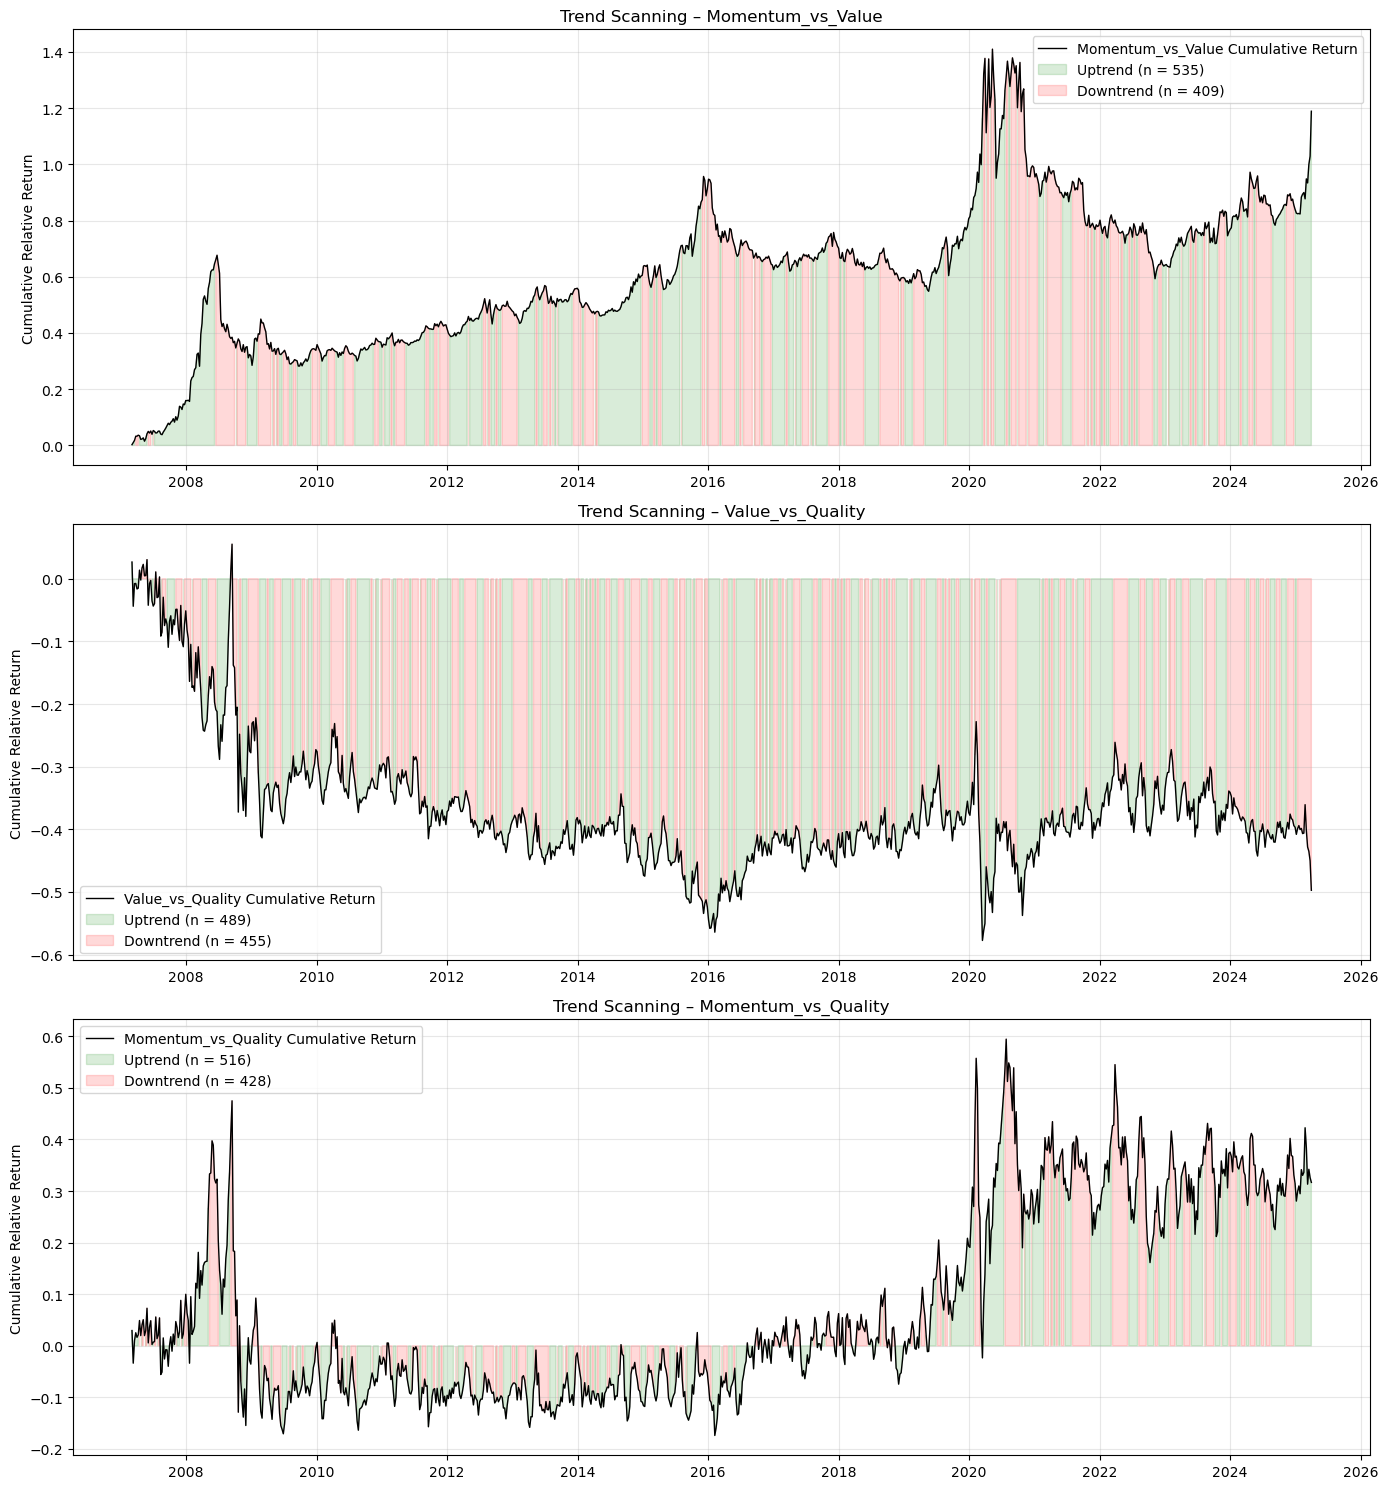

In [13]:
def plot_trend_shading_legend(df, factors):
    """
    Plot cumulative returns with shaded regions for trend signals 
    (green for uptrend, red for downtrend) for multiple factors.
    Legend includes uptrend and downtrend counts.
    """

    n_factors = len(factors)
    fig, axes = plt.subplots(n_factors, 1, figsize=(14, 5 * n_factors))

    # Ensure axes is always a list
    if n_factors == 1:
        axes = [axes]

    for i, factor in enumerate(factors):
        cum_col = f"{factor}_Cumulative"
        trend_col = f"{factor}_trend"

        if cum_col not in df.columns or trend_col not in df.columns:
            print(f"Warning: Missing columns for {factor}. Skipping.")
            continue

        ax = axes[i]

        # ===============================
        # Count uptrend and downtrend
        # ===============================
        trend_series = df[trend_col].fillna(method='ffill')
        up_count = (trend_series == 1).sum()
        down_count = (trend_series == 0).sum()

        # ===============================
        # Plot cumulative returns
        # ===============================
        ax.plot(
            df.index,
            df[cum_col],
            color="black",
            linewidth=1,
            label=f"{factor} Cumulative Return"
        )

        # ===============================
        # Trend shading
        # ===============================
        ax.fill_between(
            df.index,
            df[cum_col],
            where=(trend_series == 1),
            color="green",
            alpha=0.15,
            label=f"Uptrend (n = {up_count})"
        )

        ax.fill_between(
            df.index,
            df[cum_col],
            where=(trend_series == 0),
            color="red",
            alpha=0.15,
            label=f"Downtrend (n = {down_count})"
        )

        ax.set_title(f"Trend Scanning – {factor}")
        ax.set_ylabel("Cumulative Relative Return")
        ax.grid(True, alpha=0.3)

        # Remove duplicated legend entries
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys())

    plt.tight_layout()
    plt.show()



if __name__ == "__main__":
    # Load data
    # df = pd.read_csv('labeled_relative_factor_returns.csv', index_col=0, parse_dates=True)
    
    # Factors to plot
    factors_to_plot = ['Momentum_vs_Value', 'Value_vs_Quality', 'Momentum_vs_Quality']
    
    # Plot
    plot_trend_shading_legend(df, factors_to_plot)